# Combined RL + Cluster Analysis
Gauntlet Â· Tournament Â· High-Level Logs Â· Cluster Formations Â· Replay Candidates Â· Single Match Deep-Dive

In [20]:
import os, glob, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle, Arc
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

BASE        = 'out'
CYCLE       = 0          # which cycle's logs to analyse
K           = 30         # k-means clusters
SEED        = 42
BLUE_GOAL_Y  = -5120.0
ORANGE_GOAL_Y = 5120.0
FIELD_X, FIELD_Y = 4096, 5120
PROFILES = ['s0','s1','s2','s3','s4','s5','p1','p2','p3','d1','d2','d3','d4']
PROF_COLORS = plt.cm.tab20(np.linspace(0,1,len(PROFILES)))
PROF_CMAP   = {p: PROF_COLORS[i] for i,p in enumerate(PROFILES)}

HIGH_LOG_DIR  = f'{BASE}/tournament_high_logs/{CYCLE}'
CLUSTER_LOG   = f'{BASE}/cluster_logs/{CYCLE}/cluster_rewards.csv'
CLUSTER_NPY   = f'{BASE}/formation_clusters/{CYCLE}'

def parse_tuple(s):
    m = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', str(s))
    return (float(m[0]), float(m[1])) if len(m)>=2 else (0.,0.)

def ball_speed(df):
    return np.sqrt(df.ball_vx**2 + df.ball_vy**2 + df.ball_vz**2)

def car_speed(df, slot):
    return np.sqrt(df[f'{slot}_vx']**2 + df[f'{slot}_vy']**2 + df[f'{slot}_vz']**2)

# â”€â”€ load gauntlet logs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ll = pd.read_csv(f'{BASE}/low_level_log.csv')
rc = pd.read_csv(f'{BASE}/reward_contrib.csv')
trn_raw = pd.read_csv(f'{BASE}/tournament_logs.csv', header=None, skip_blank_lines=True).dropna(how='all')
trn_raw.columns = ll.columns[:len(trn_raw.columns)]
trn = trn_raw.copy()
trn['match_id'] = pd.to_numeric(trn['match_id'], errors='coerce')
trn = trn.dropna(subset=['match_id'])
for col in ['blue_score','orange_score','goal_diff','blue_switches','orange_switches']:
    if col in trn.columns:
        trn[col] = pd.to_numeric(trn[col], errors='coerce').fillna(0).astype(int)

# â”€â”€ load high-level logs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
csv_files = sorted(glob.glob(f'{HIGH_LOG_DIR}/*.csv'))
hl_dfs = []
for f in csv_files:
    try:
        df = pd.read_csv(f)
        name = os.path.basename(f).replace('.csv','')
        mid  = int(name.split(')')[0])
        parts = name.split(')',1)[1].split('v',1) if ')' in name else ['',''] 
        df['_match_id'] = mid
        df['_blue_team']   = parts[0]
        df['_orange_team'] = parts[1] if len(parts)>1 else ''
        hl_dfs.append(df)
    except Exception as e:
        print(f'skip {f}: {e}')
hl_all = pd.concat(hl_dfs, ignore_index=True) if hl_dfs else pd.DataFrame()

# â”€â”€ load cluster log â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cl = pd.read_csv(CLUSTER_LOG) if os.path.exists(CLUSTER_LOG) else pd.DataFrame()

# â”€â”€ load cluster npy â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
feat_path = f'{CLUSTER_NPY}/features.npy'
meta_path = f'{CLUSTER_NPY}/metadata.npy'
if os.path.exists(feat_path):
    features = np.load(feat_path)
    metadata = np.load(meta_path, allow_pickle=True)
    meta_df  = pd.DataFrame({'match_id': metadata['match_id'],
                              'tick':     metadata['tick'],
                              'perspective': metadata['perspective']})
    # k-means
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    km = MiniBatchKMeans(n_clusters=K, random_state=SEED, n_init=5)
    km.fit(X)
    labels = km.labels_
    centroids_orig = scaler.inverse_transform(km.cluster_centers_)
    meta_df['cluster'] = labels
    print(f'Loaded {len(features)} formation datapoints, {K} clusters.')
else:
    features = None; meta_df = pd.DataFrame(); centroids_orig = None
    print('No cluster npy found â€” cluster cells will be skipped.')

print(f'HL logs: {len(hl_dfs)} files, {len(hl_all)} rows')
print(f'Cluster log: {len(cl)} replays')
print(f'Gauntlet: {len(ll)} matches   Tournament: {len(trn)} matches')

Loaded 111734 formation datapoints, 30 clusters.
HL logs: 62 files, 279168 rows
Cluster log: 4678 replays
Gauntlet: 2604 matches   Tournament: 154 matches


## 1. Ball Location Heatmap & Goal Scoring Over Time

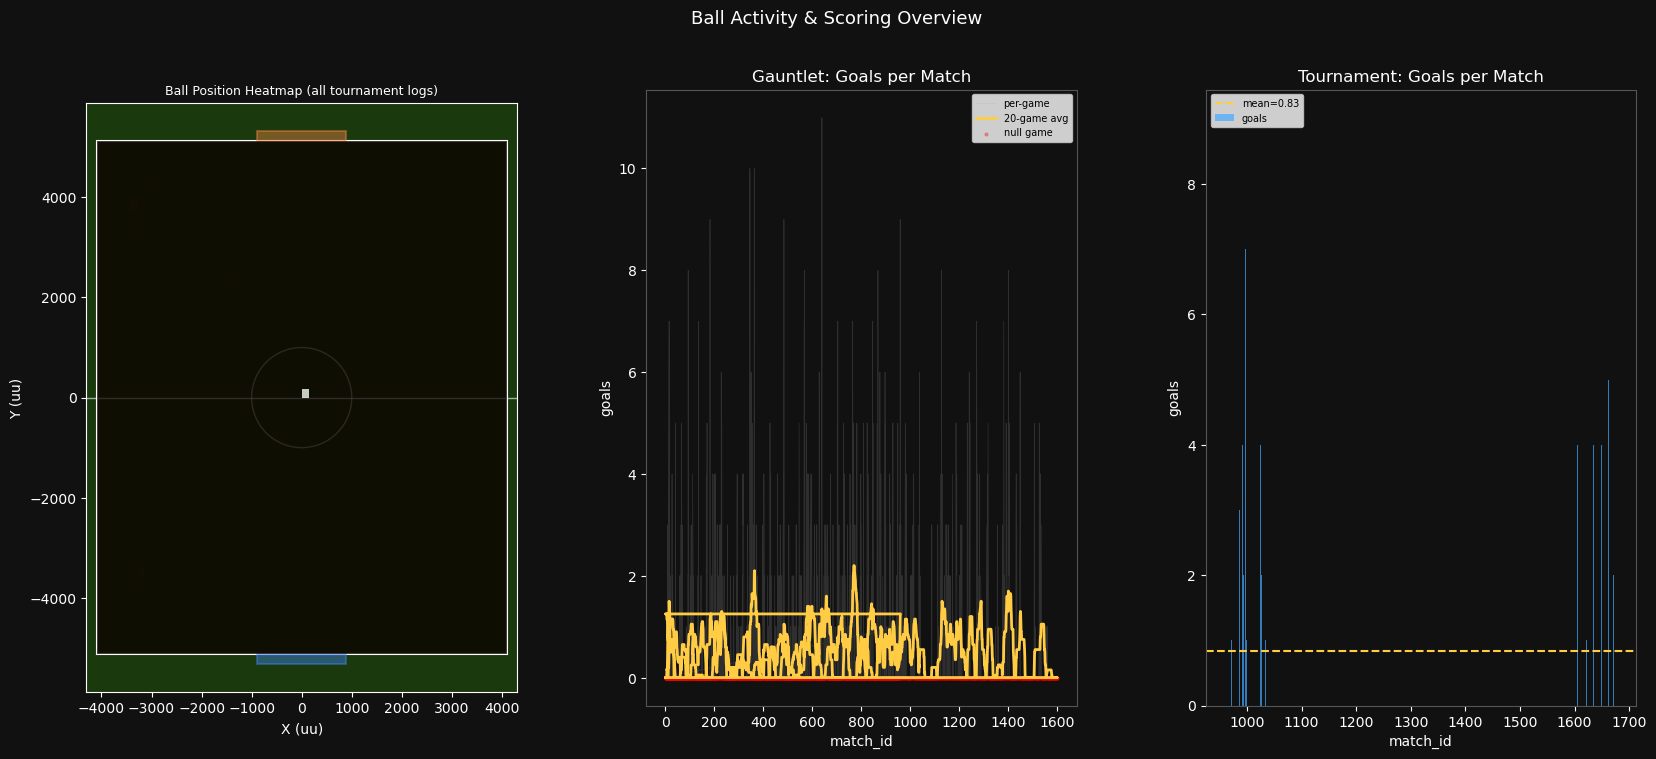

In [21]:
def draw_field(ax, title='', flip_y=False):
    ax.set_facecolor('#2d5a1b')
    sign = -1 if flip_y else 1
    # field outline
    ax.add_patch(Rectangle((-FIELD_X, -FIELD_Y*sign), 2*FIELD_X, 2*FIELD_Y*sign,
                            fill=False, edgecolor='white', lw=1.5))
    # midfield line
    ax.axhline(0, color='white', lw=1, alpha=0.6)
    # goals
    for gy, col in [(BLUE_GOAL_Y, '#4488ff'), (ORANGE_GOAL_Y, '#ff8844')]:
        ax.add_patch(Rectangle((-893, gy*sign), 1786, 200*sign if gy>0 else -200*sign,
                                fill=True, facecolor=col, alpha=0.4, edgecolor=col, lw=1.5))
    # centre circle
    ax.add_patch(Circle((0,0), 1000, fill=False, edgecolor='white', lw=1, alpha=0.5))
    ax.set_xlim(-FIELD_X*1.05, FIELD_X*1.05)
    ax.set_ylim(-FIELD_Y*1.15, FIELD_Y*1.15)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=9, color='white')
    ax.tick_params(colors='white'); ax.set_facecolor('#1a3a0e')
    for sp in ax.spines.values(): sp.set_color('white')

fig = plt.figure(figsize=(20, 8))
gs  = GridSpec(1, 3, figure=fig, wspace=0.3)

# --- Ball heatmap (all HL logs) ---
ax1 = fig.add_subplot(gs[0])
if len(hl_all) > 0:
    h, xe, ye = np.histogram2d(hl_all['ball_px'], hl_all['ball_py'],
                                bins=60, range=[[-FIELD_X,FIELD_X],[-FIELD_Y,FIELD_Y]])
    draw_field(ax1, 'Ball Position Heatmap (all tournament logs)')
    ax1.pcolormesh(xe, ye, h.T, cmap='hot', alpha=0.75, zorder=2)
    ax1.set_xlabel('X (uu)', color='white'); ax1.set_ylabel('Y (uu)', color='white')

# --- Goals per match (gauntlet trend) ---
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#111')
window = 20
rc_goals = rc['blue_score'] + rc['orange_score']
rolled   = rc_goals.rolling(window, min_periods=1).mean()
ax2.plot(rc['match_id'], rc_goals, alpha=0.2, color='#aaa', lw=0.5, label='per-game')
ax2.plot(rc['match_id'], rolled, color='#ffcc44', lw=2, label=f'{window}-game avg')
null_mask = rc_goals == 0
ax2.scatter(rc.loc[null_mask,'match_id'], [0]*null_mask.sum(), s=4, color='red', alpha=0.3, label='null game')
ax2.set_title('Gauntlet: Goals per Match', color='white'); ax2.legend(fontsize=7)
ax2.set_xlabel('match_id', color='white'); ax2.set_ylabel('goals', color='white')
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_color('#555')

# --- Goals per match (tournament) ---
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor('#111')
if len(trn) > 0:
    trn_goals = trn['blue_score'] + trn['orange_score']
    ax3.bar(trn['match_id'], trn_goals, color='#44aaff', alpha=0.7, width=0.8, label='goals')
    ax3.axhline(trn_goals.mean(), color='#ffcc44', lw=1.5, ls='--', label=f'mean={trn_goals.mean():.2f}')
    ax3.set_title('Tournament: Goals per Match', color='white'); ax3.legend(fontsize=7)
    ax3.set_xlabel('match_id', color='white'); ax3.set_ylabel('goals', color='white')
    ax3.tick_params(colors='white')
    for sp in ax3.spines.values(): sp.set_color('#555')
fig.patch.set_facecolor('#111')
plt.suptitle('Ball Activity & Scoring Overview', color='white', fontsize=13)
plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

## 2. Reward Accrual Over Training

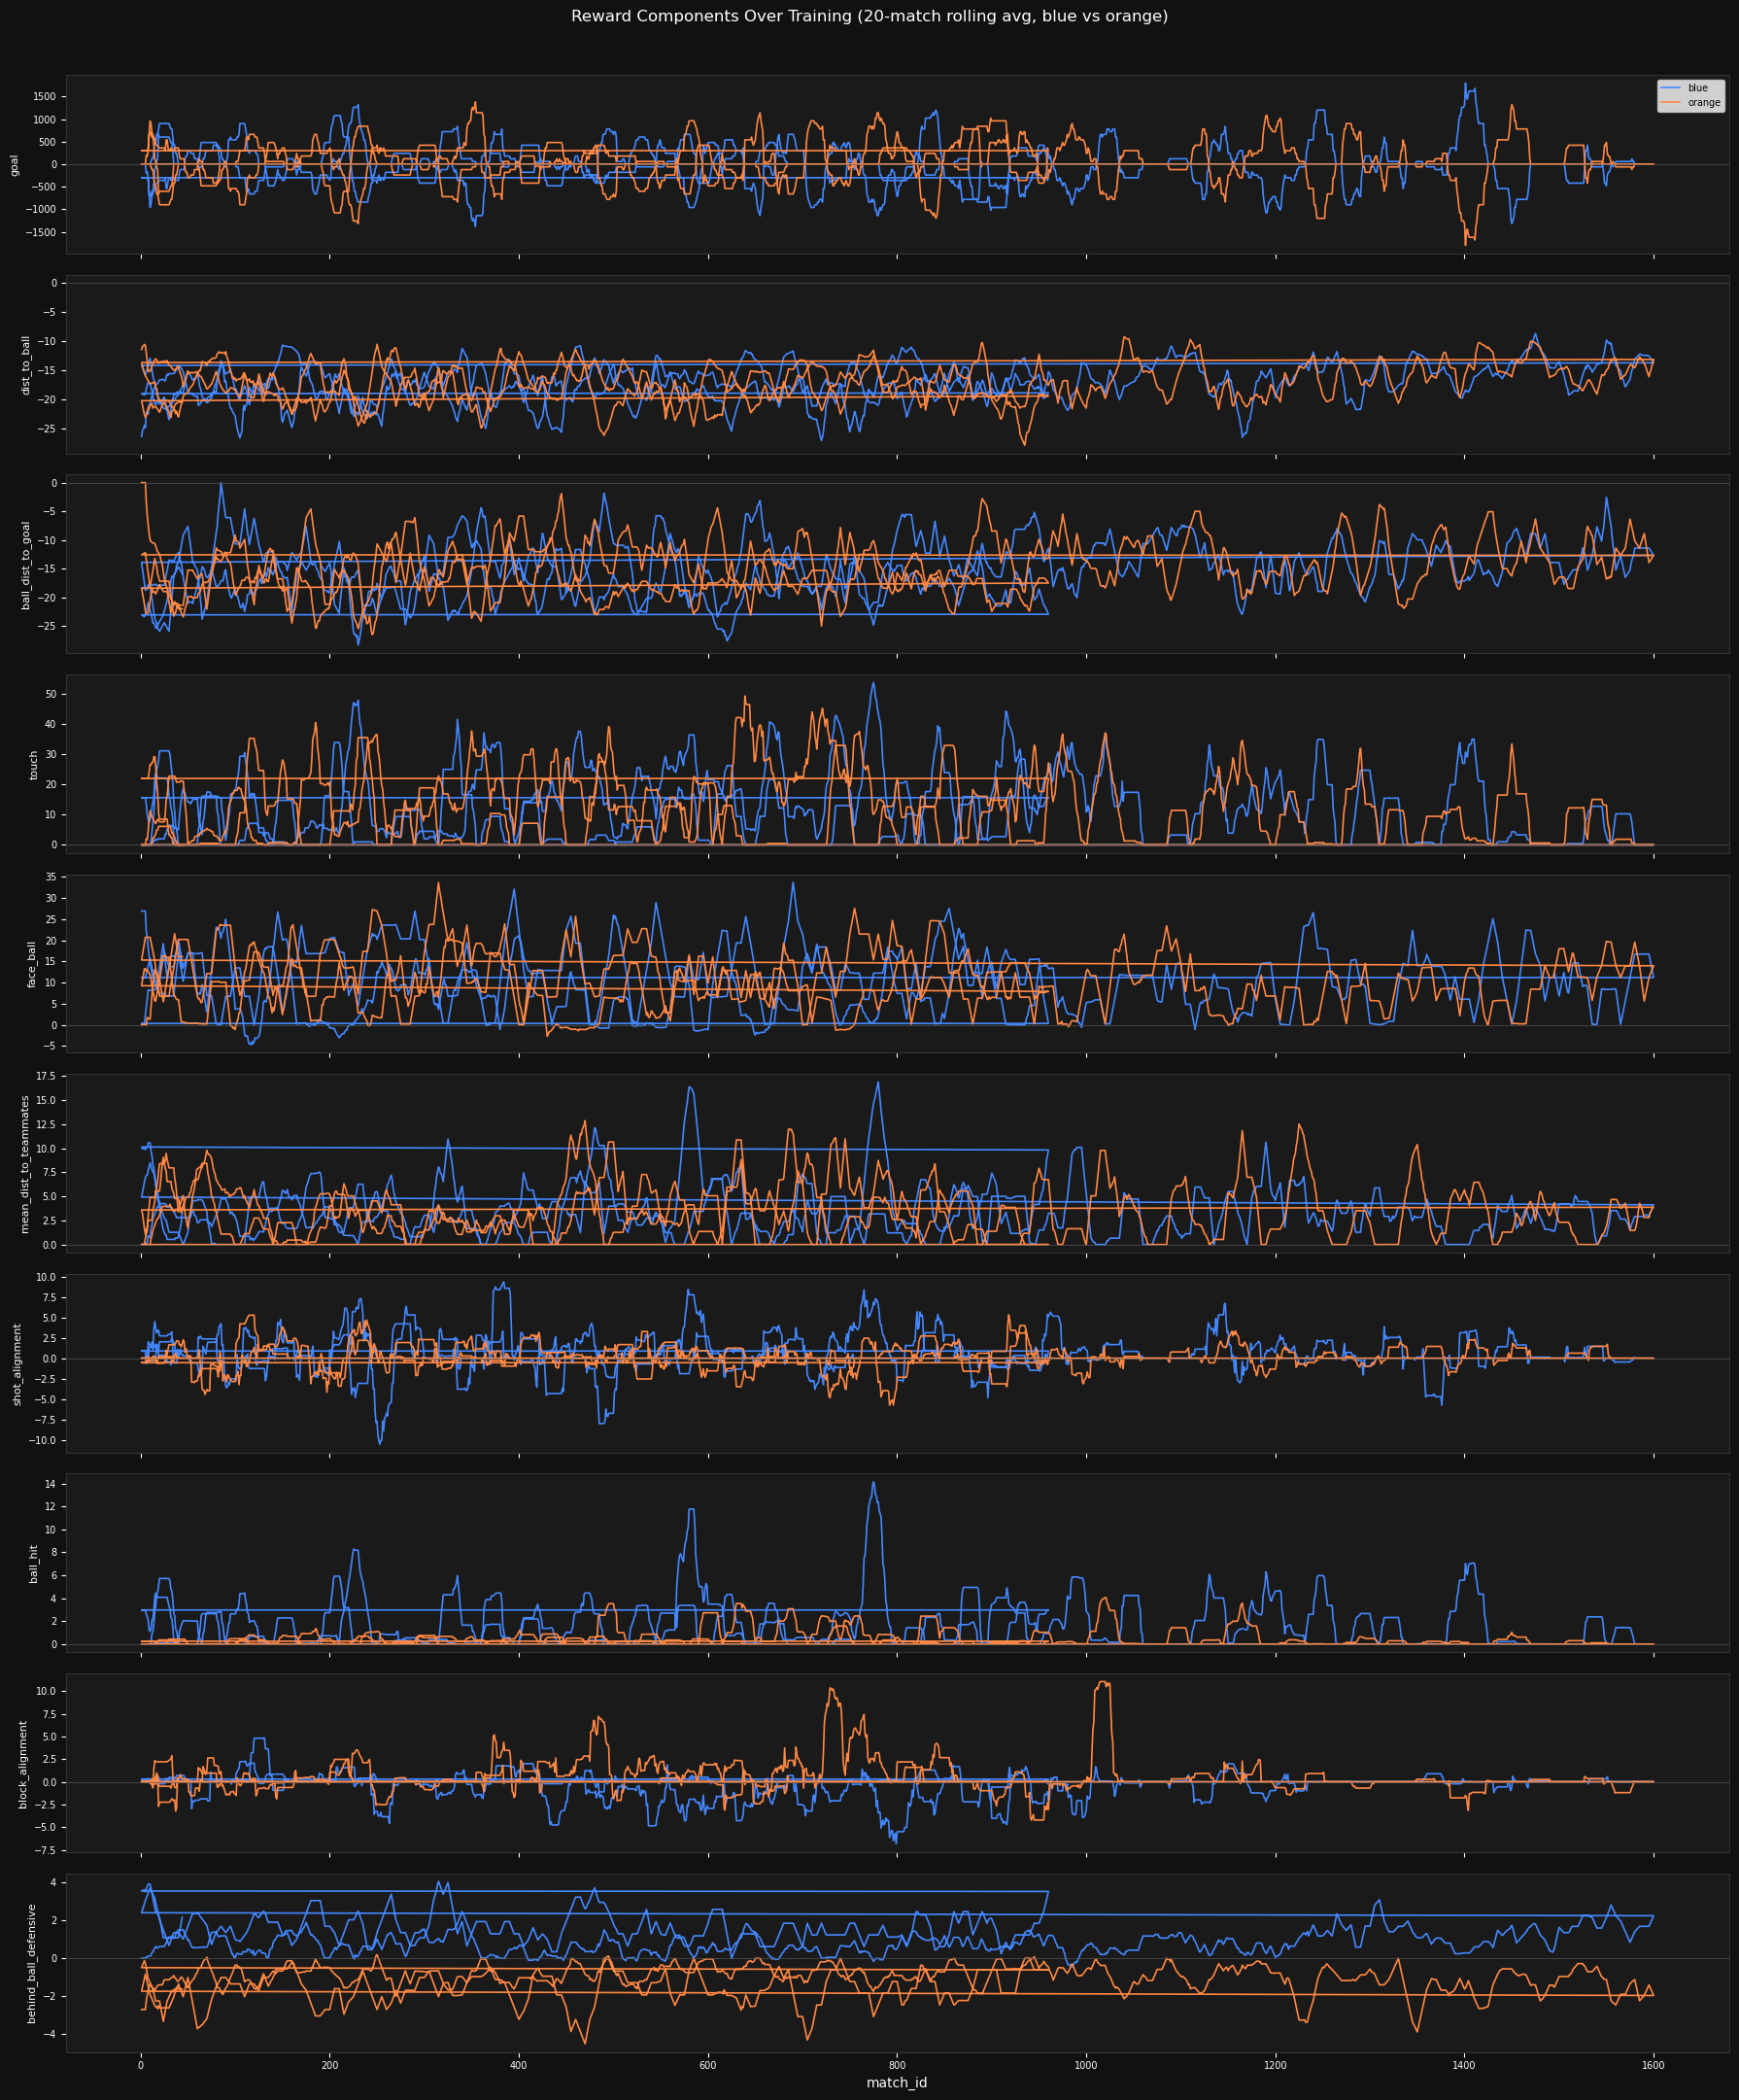

In [22]:
reward_cols = [c for c in rc.columns if c.startswith('r_')]
rb = pd.DataFrame({c: rc[c].apply(lambda s: parse_tuple(s)[0]) for c in reward_cols})
ro = pd.DataFrame({c: rc[c].apply(lambda s: parse_tuple(s)[1]) for c in reward_cols})

# rank by abs mean
top_cols = rb.abs().mean().sort_values(ascending=False).index.tolist()
n_plot   = min(10, len(top_cols))
W = 20

fig, axes = plt.subplots(n_plot, 1, figsize=(18, 2.2*n_plot), sharex=True)
fig.patch.set_facecolor('#111')
if n_plot == 1: axes = [axes]
for ax, col in zip(axes, top_cols[:n_plot]):
    ax.set_facecolor('#1a1a1a')
    bv = rb[col].rolling(W, min_periods=1).mean()
    ov = ro[col].rolling(W, min_periods=1).mean()
    ax.plot(rc['match_id'], bv, color='#4488ff', lw=1.2, label='blue')
    ax.plot(rc['match_id'], ov, color='#ff8844', lw=1.2, label='orange')
    ax.axhline(0, color='#555', lw=0.5)
    ax.set_ylabel(col[2:], color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for sp in ax.spines.values(): sp.set_color('#333')
    if ax == axes[0]: ax.legend(fontsize=7, loc='upper right')
axes[-1].set_xlabel('match_id', color='white')
plt.suptitle(f'Reward Components Over Training ({W}-match rolling avg, blue vs orange)', color='white', fontsize=12)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

## 3. Agent Deployment â€” Who Plays Where

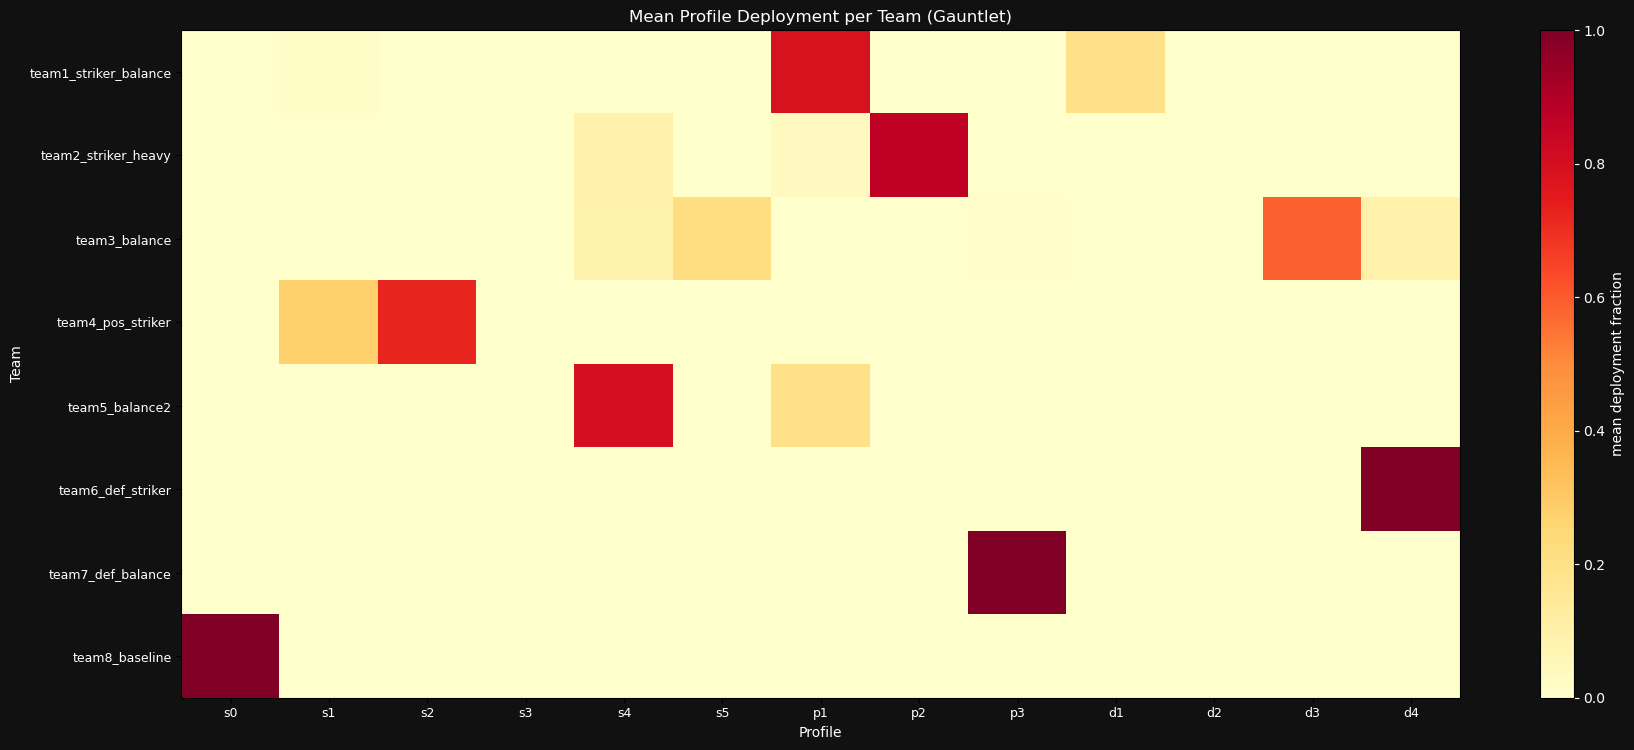

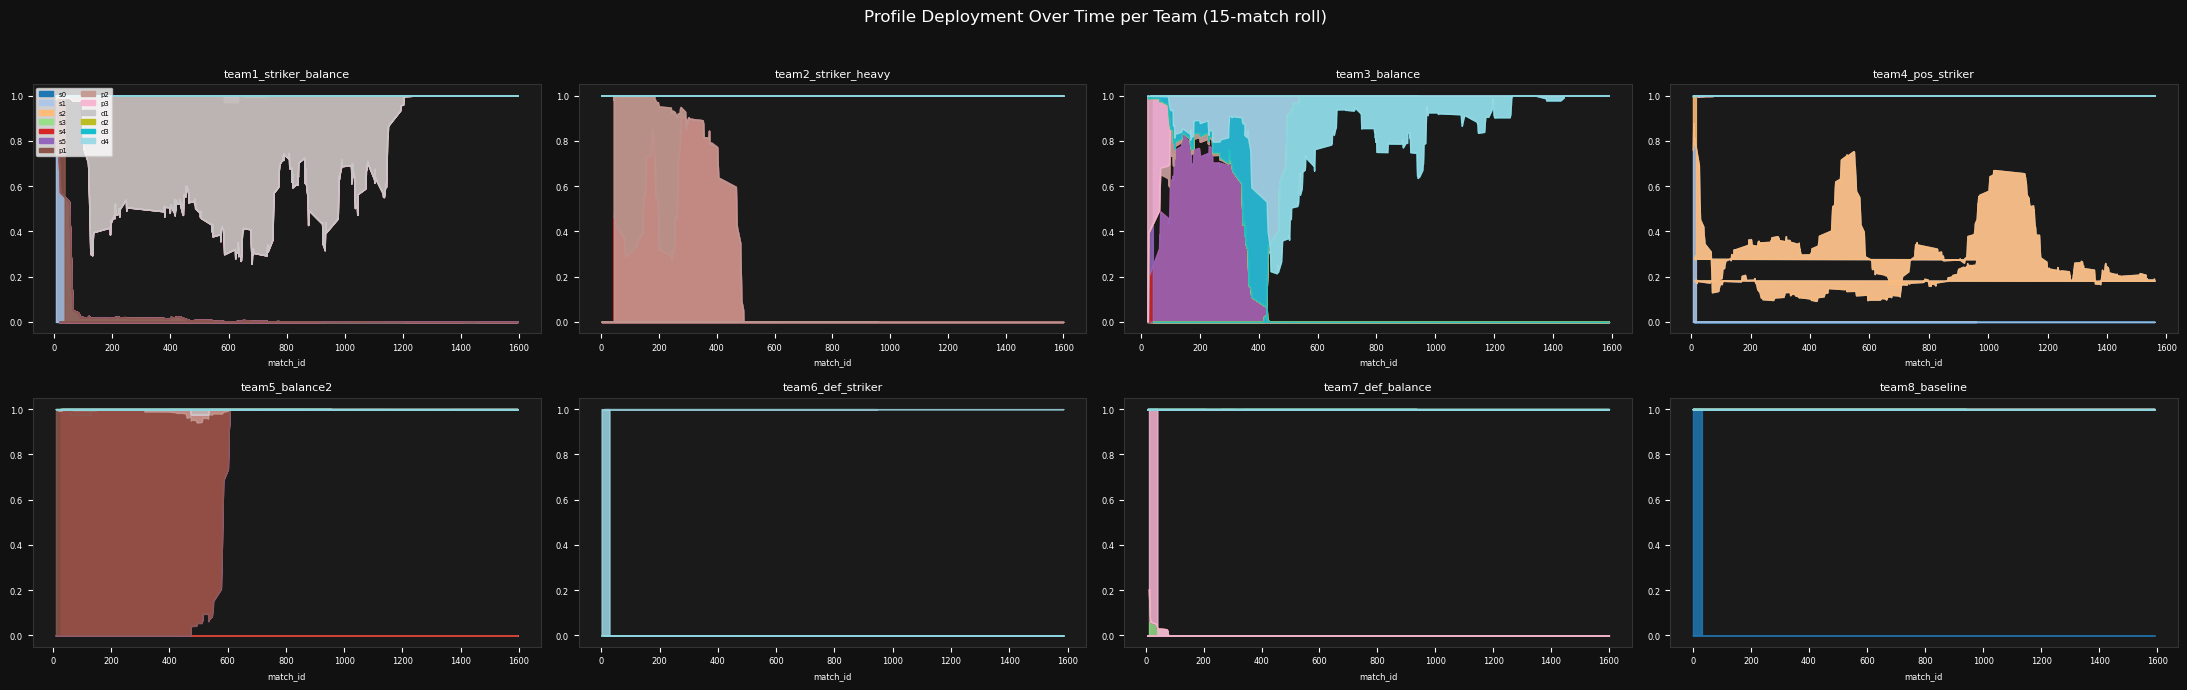

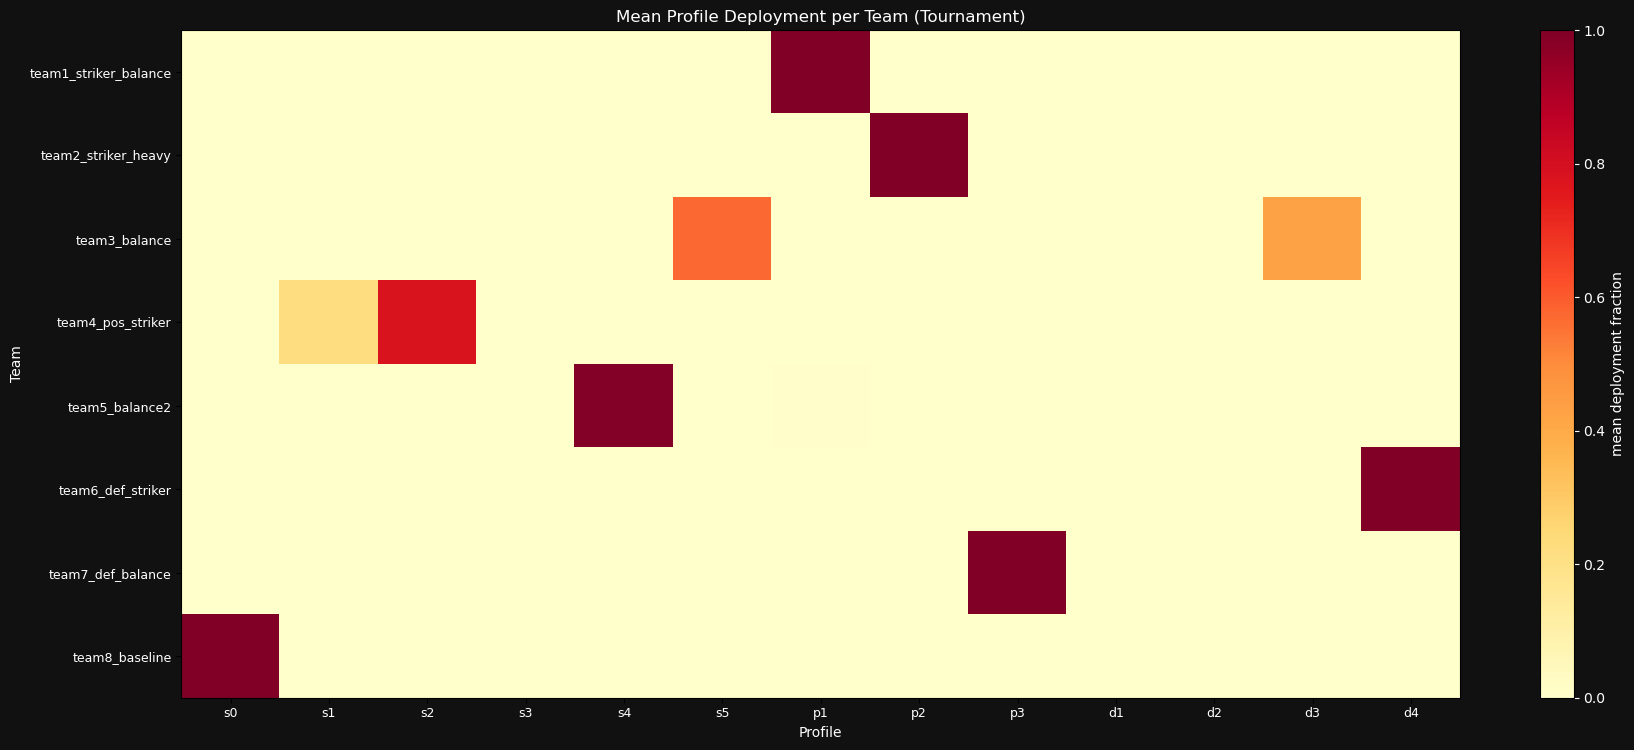

In [23]:
from collections import defaultdict

# ── Build per-team deployment aggregation ─────────────────────────────────
prof_available = [p for p in PROFILES if f'contrib_{p}' in ll.columns]

team_records = defaultdict(lambda: {p: [] for p in prof_available})
for _, row in ll.iterrows():
    bt = str(row.get('blue_team', ''))
    ot = str(row.get('orange_team', ''))
    for p in prof_available:
        col = f'contrib_{p}'
        bv, ov = parse_tuple(row[col])
        if bt: team_records[bt][p].append(bv)
        if ot: team_records[ot][p].append(ov)

teams_sorted = sorted(k for k in team_records if k)

# teams × profiles mean matrix
team_mat = np.zeros((len(teams_sorted), len(PROFILES)))
for ti, team in enumerate(teams_sorted):
    for pi, p in enumerate(PROFILES):
        vals = team_records[team].get(p, [])
        team_mat[ti, pi] = np.mean(vals) if vals else 0.0

# ── Fig 1: Gauntlet heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, max(4, len(teams_sorted) * 0.7 + 2)))
fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')
im = ax.imshow(team_mat, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(PROFILES))); ax.set_xticklabels(PROFILES, color='white', fontsize=9)
ax.set_yticks(range(len(teams_sorted))); ax.set_yticklabels(teams_sorted, color='white', fontsize=9)
ax.set_xlabel('Profile', color='white'); ax.set_ylabel('Team', color='white')
cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
cbar.ax.set_ylabel('mean deployment fraction', color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax.set_title('Mean Profile Deployment per Team (Gauntlet)', color='white', fontsize=12)
plt.tight_layout(); plt.show()

# ── Fig 2: Per-team stacked area over time ───────────────────────────────
N_TEAMS = len(teams_sorted)
COLS_T = min(4, N_TEAMS)
ROWS_T = max(1, int(np.ceil(N_TEAMS / COLS_T)))
W_T = 15
fig, axes = plt.subplots(ROWS_T, COLS_T, figsize=(COLS_T * 5.5, ROWS_T * 3.5))
fig.patch.set_facecolor('#111')
axes_flat = np.array(axes).flatten() if N_TEAMS > 1 else [axes]

for ti, team in enumerate(teams_sorted):
    ax = axes_flat[ti]; ax.set_facecolor('#1a1a1a')
    mask_b = ll['blue_team'] == team
    mask_o = ll['orange_team'] == team
    sub = ll[mask_b | mask_o].copy()
    if len(sub) == 0:
        ax.set_title(team, color='white', fontsize=8); continue
    sub['_is_blue'] = mask_b.loc[sub.index].values
    bot = np.zeros(len(sub))
    for p in PROFILES:
        col = f'contrib_{p}'
        if col not in ll.columns: continue
        bv = sub[col].apply(lambda s: parse_tuple(s)[0])
        ov = sub[col].apply(lambda s: parse_tuple(s)[1])
        vals = np.where(sub['_is_blue'], bv, ov)
        rv = pd.Series(vals).rolling(W_T, min_periods=1).mean().values
        ax.fill_between(sub['match_id'], bot, bot + rv, color=PROF_CMAP[p], alpha=0.85, label=p)
        bot += rv
    ax.set_title(team, color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=6)
    ax.set_xlabel('match_id', color='white', fontsize=6)
    for sp in ax.spines.values(): sp.set_color('#333')
    if ti == 0:
        handles = [mpatches.Patch(color=PROF_CMAP[p], label=p) for p in PROFILES if p in PROF_CMAP]
        ax.legend(handles=handles, fontsize=5, loc='upper left', ncol=2)

for ax in axes_flat[N_TEAMS:]:
    ax.set_visible(False)

plt.suptitle(f'Profile Deployment Over Time per Team ({W_T}-match roll)', color='white', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# ── Fig 3: Tournament heatmap ────────────────────────────────────────────
if len(trn) > 0 and 'blue_team' in trn.columns and f'contrib_{PROFILES[0]}' in trn.columns:
    trn_records = defaultdict(lambda: {p: [] for p in prof_available})
    for _, row in trn.iterrows():
        bt = str(row.get('blue_team', ''))
        ot = str(row.get('orange_team', ''))
        for p in prof_available:
            col = f'contrib_{p}'
            if col not in trn.columns: continue
            bv, ov = parse_tuple(row[col])
            if bt: trn_records[bt][p].append(bv)
            if ot: trn_records[ot][p].append(ov)
    trn_teams = sorted(k for k in trn_records if k)
    if trn_teams:
        trn_mat = np.zeros((len(trn_teams), len(PROFILES)))
        for ti, team in enumerate(trn_teams):
            for pi, p in enumerate(PROFILES):
                vals = trn_records[team].get(p, [])
                trn_mat[ti, pi] = np.mean(vals) if vals else 0.0
        fig, ax = plt.subplots(figsize=(18, max(4, len(trn_teams) * 0.7 + 2)))
        fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')
        im = ax.imshow(trn_mat, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(PROFILES))); ax.set_xticklabels(PROFILES, color='white', fontsize=9)
        ax.set_yticks(range(len(trn_teams))); ax.set_yticklabels(trn_teams, color='white', fontsize=9)
        ax.set_xlabel('Profile', color='white'); ax.set_ylabel('Team', color='white')
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
        cbar.ax.set_ylabel('mean deployment fraction', color='white')
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
        ax.set_title('Mean Profile Deployment per Team (Tournament)', color='white', fontsize=12)
        plt.tight_layout(); plt.show()
    else:
        print('No tournament team data — skipping.')
else:
    print('No tournament team columns — skipping.')


## 4. Cluster Field Visualizations with 2D Motion Vectors

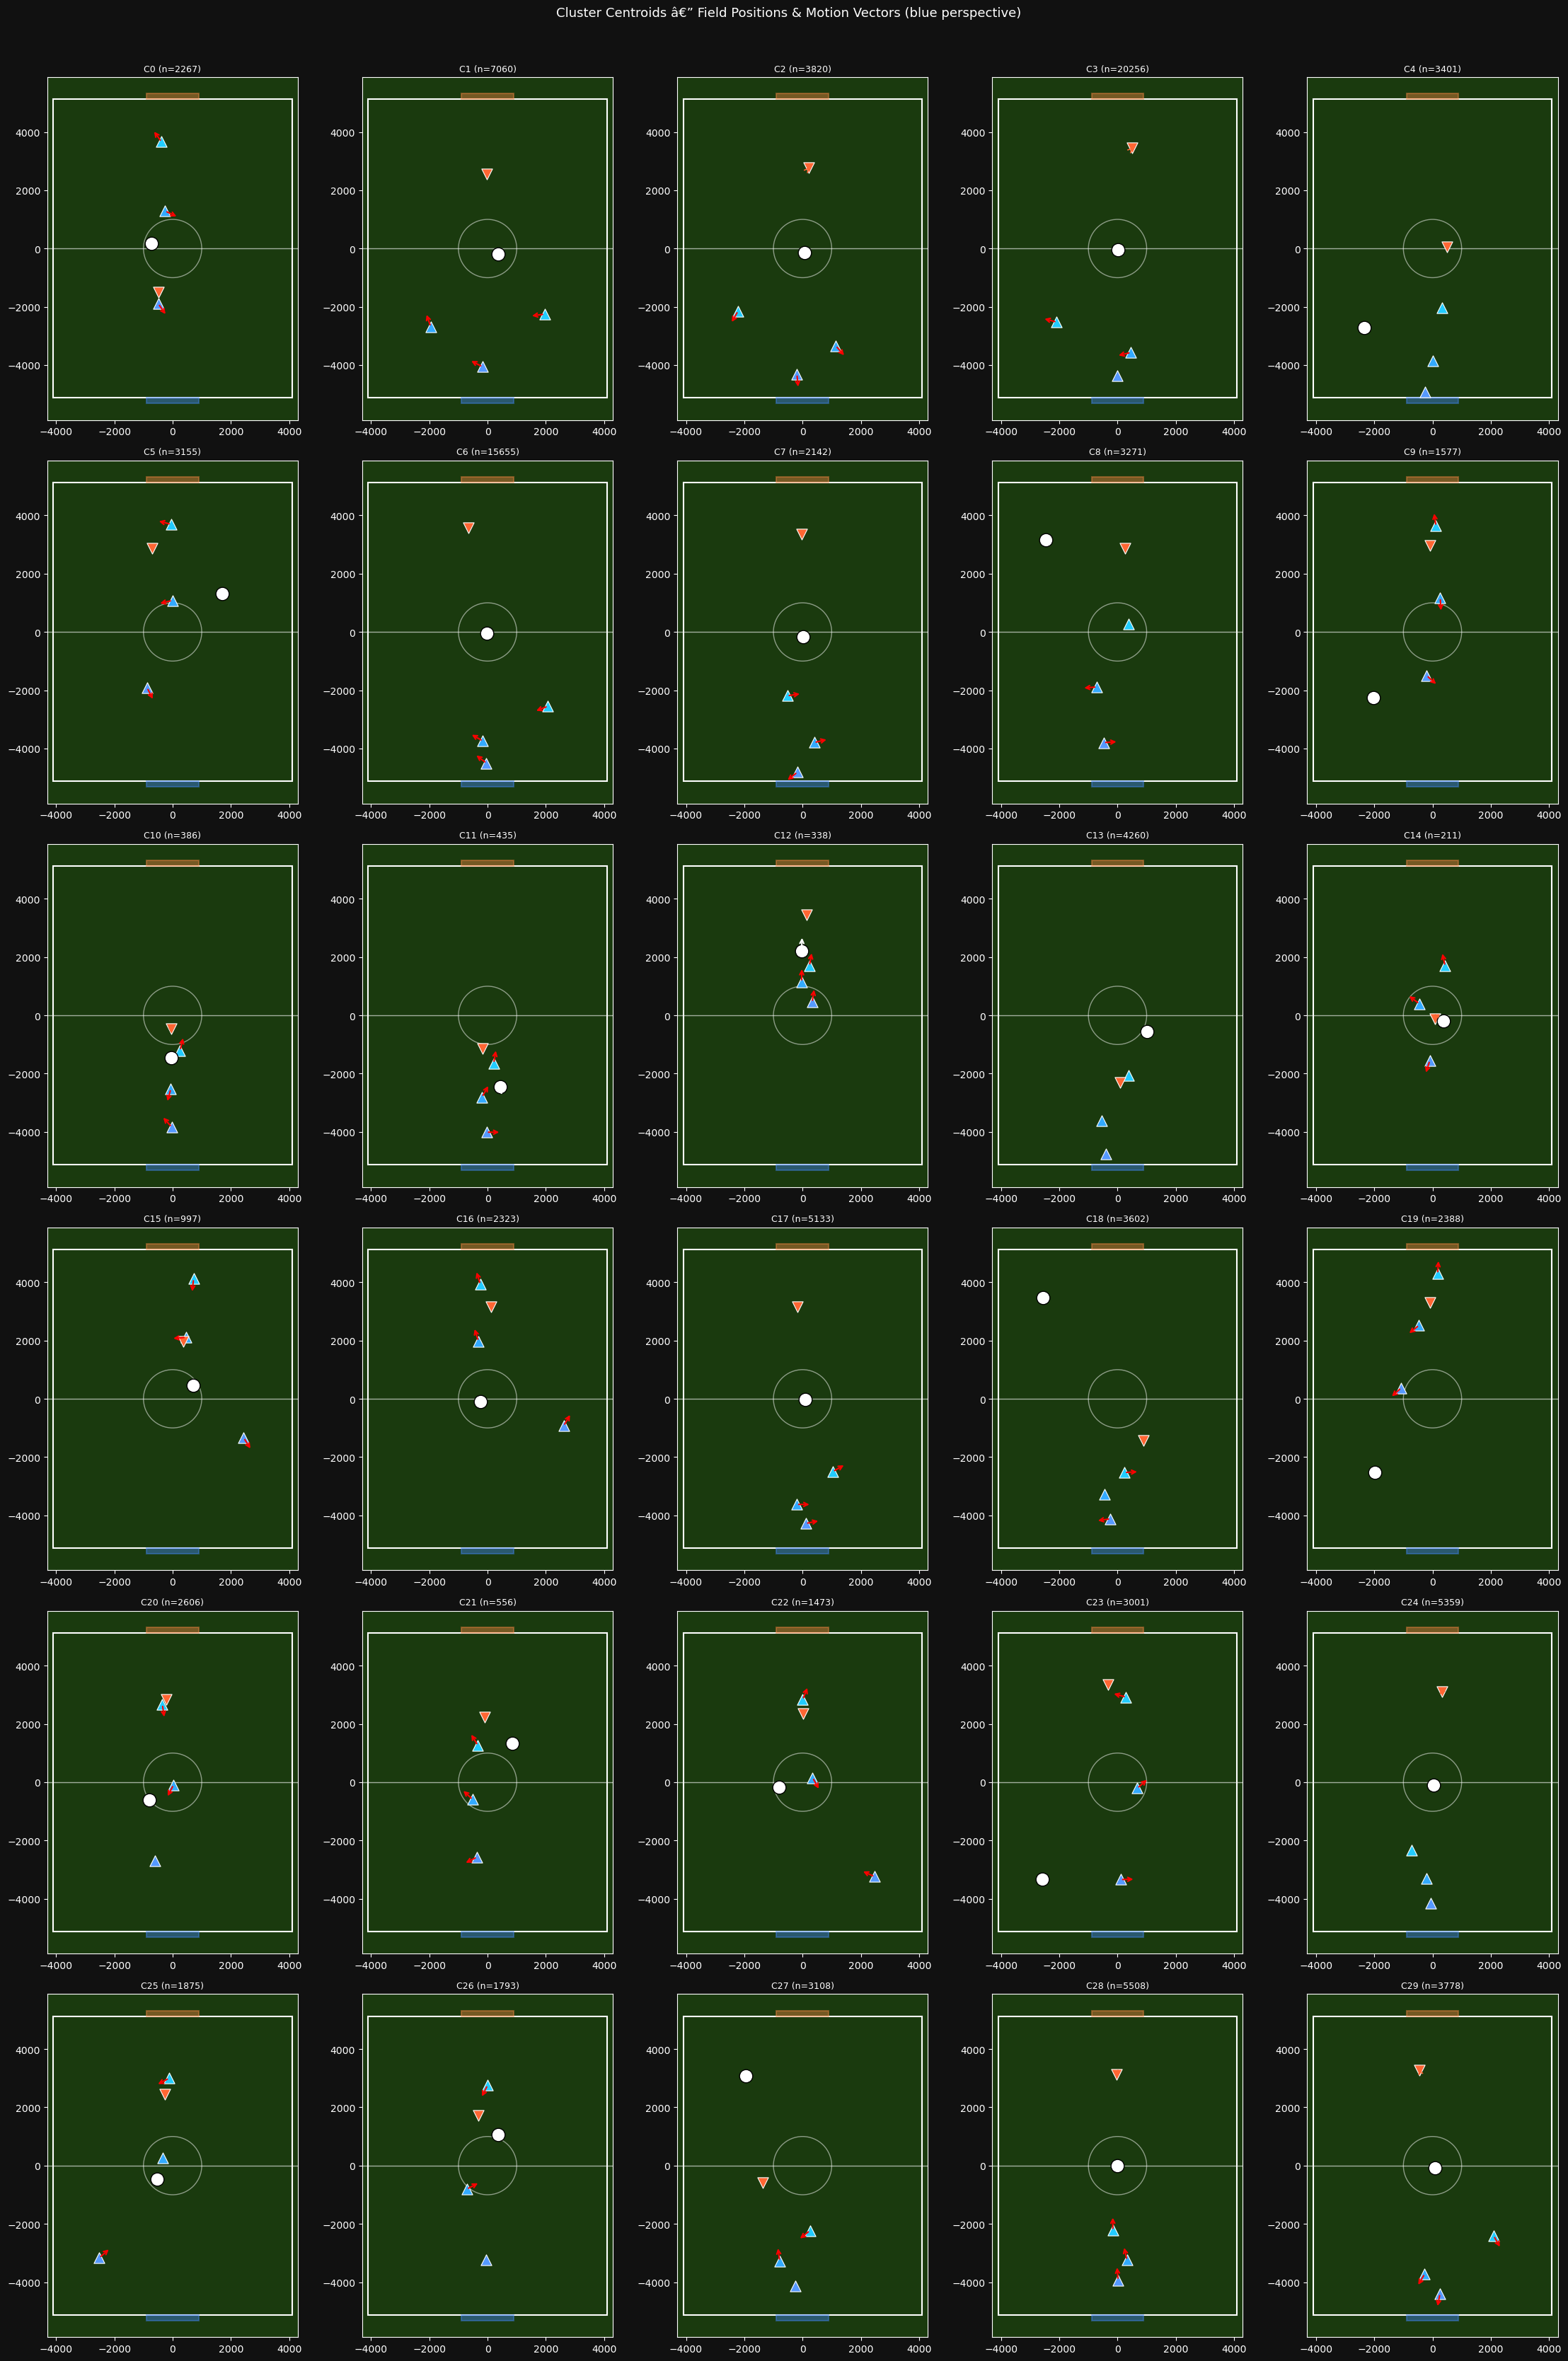

In [24]:
if features is None:
    print('No cluster data â€” skipping.')
else:
    # centroid layout: 5 cols Ã— ceil(K/5) rows
    N_COLS = 5
    N_ROWS = int(np.ceil(K / N_COLS))
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS*4.5, N_ROWS*5.5))
    fig.patch.set_facecolor('#111')
    axes_flat = axes.flatten() if K > 1 else [axes]

    feat_names = [
        'ball_px','ball_py','ball_pz','ball_vx','ball_vy','ball_vz',
        'own0_px','own0_py','own0_pz','own0_vx','own0_vy',
        'own1_px','own1_py','own1_pz','own1_vx','own1_vy',
        'own2_px','own2_py','own2_pz','own2_vx','own2_vy',
        'opp_cx','opp_cy','opp_cvx','opp_cvy','opp_dist','opp_medx','opp_medy'
    ]

    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    for cid in range(K):
        ax = axes_flat[cid]
        draw_field(ax, f'C{cid} (n={cluster_sizes.get(cid,0)})')
        c = centroids_orig[cid]
        d = dict(zip(feat_names, c))

        # Ball â€” position dot + velocity arrow
        bx, by = d['ball_px'], d['ball_py']
        ax.scatter([bx],[by], s=180, color='white', zorder=5, edgecolors='black', lw=1)
        bvx, bvy = d['ball_vx']*0.25, d['ball_vy']*0.25
        if abs(bvx)+abs(bvy) > 50:
            ax.annotate('', xy=(bx+bvx, by+bvy), xytext=(bx, by),
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.5), zorder=6)

        # Own cars (blue perspective) — marker + red orientation arrow (mean velocity direction)
        ORIENT_LEN = 500
        for i, col in enumerate(['#5599ff','#33aaff','#22ccff']):
            px = d[f'own{i}_px']; py = d[f'own{i}_py']
            vx = d[f'own{i}_vx']; vy = d[f'own{i}_vy']
            ax.scatter([px],[py], s=120, color=col, zorder=4, marker='^', edgecolors='white', lw=0.8)
            vmag = float(np.sqrt(vx**2 + vy**2))
            if vmag > 50:
                nx, ny = vx / vmag * ORIENT_LEN, vy / vmag * ORIENT_LEN
                ax.annotate('', xy=(px+nx, py+ny), xytext=(px, py),
                            arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=6)

        # Opponent centroid + velocity
        ocx, ocy = d['opp_cx'], d['opp_cy']
        ovx, ovy = d['opp_cvx']*0.2, d['opp_cvy']*0.2
        ax.scatter([ocx],[ocy], s=120, color='#ff6633', zorder=4, marker='v', edgecolors='white', lw=0.8)
        if abs(ovx)+abs(ovy) > 30:
            ax.annotate('', xy=(ocx+ovx, ocy+ovy), xytext=(ocx, ocy),
                        arrowprops=dict(arrowstyle='->', color='#ff6633', lw=1.2), zorder=5)

    for ax in axes_flat[K:]:
        ax.set_visible(False)

    plt.suptitle('Cluster Centroids â€” Field Positions & Motion Vectors (blue perspective)',
                 color='white', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

## 5. Profile Behavior Per Cluster

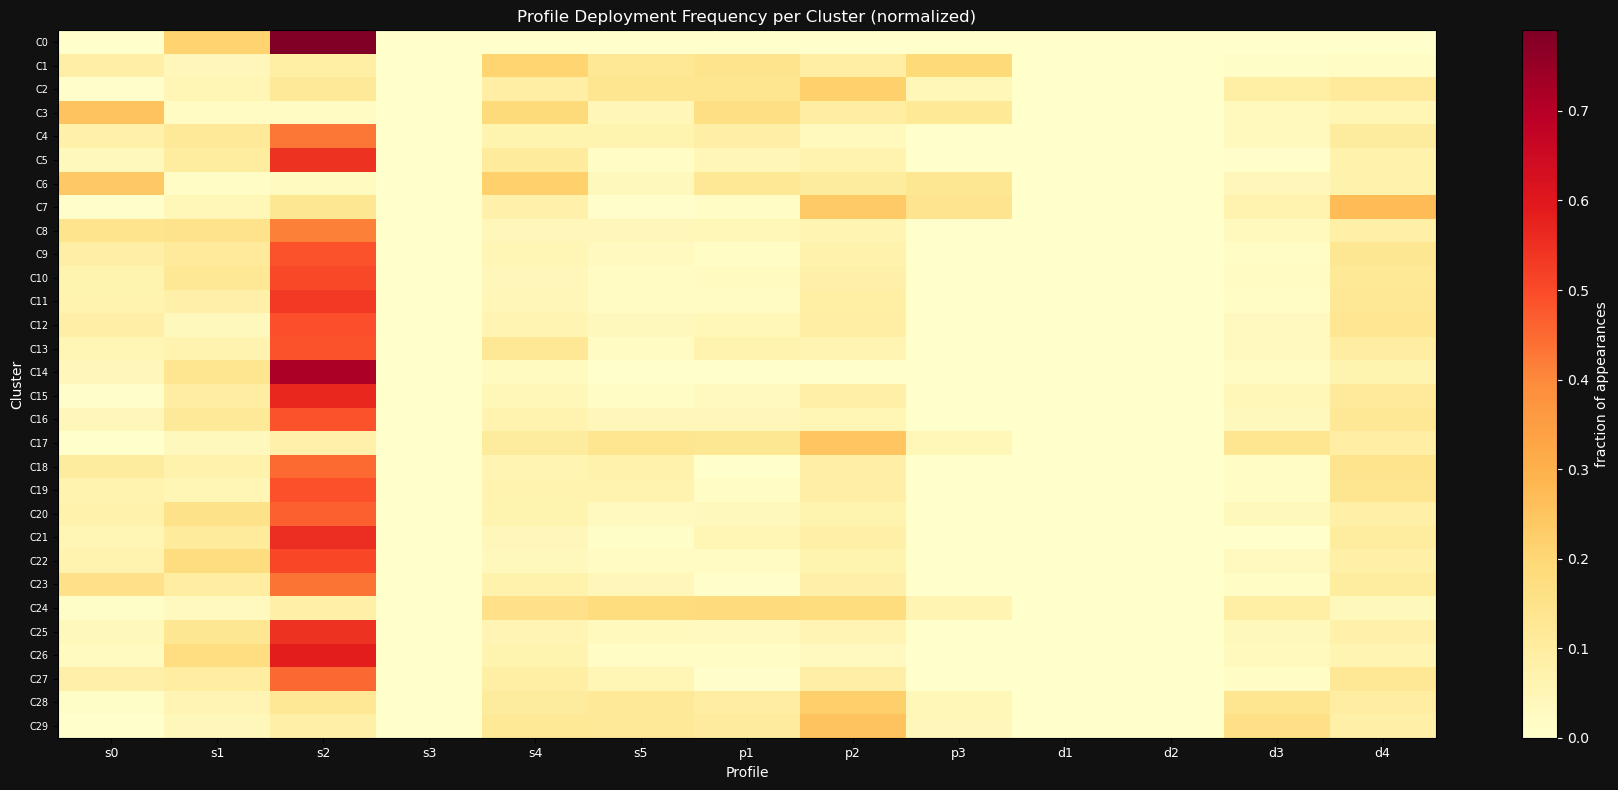

In [25]:
if features is None or len(hl_all) == 0:
    print('Need both cluster data and HL logs â€” skipping.')
else:
    # Join cluster labels back to raw HL rows by (match_id, tick)
    meta_df['_key'] = meta_df['match_id'].astype(str) + '_' + meta_df['tick'].astype(str)
    hl_all['_key']  = hl_all['match_id'].astype(str) + '_' + hl_all['tick'].astype(str)
    hl_merged = hl_all.merge(meta_df[['_key','cluster']], on='_key', how='inner')

    if len(hl_merged) == 0:
        print('No HL rows matched cluster ticks.')
    else:
        # For each cluster, count profile appearances across all car slots
        slot_cols = [f'{side}-{i}_profile' for side in ['blue','orange'] for i in range(3)]
        slot_cols = [c for c in slot_cols if c in hl_merged.columns]

        cluster_prof = {}
        for cid in range(K):
            rows = hl_merged[hl_merged['cluster']==cid]
            counts = {}
            for col in slot_cols:
                for v in rows[col].dropna():
                    counts[v] = counts.get(v,0) + 1
            cluster_prof[cid] = counts

        # Build matrix: clusters Ã— profiles
        mat = np.zeros((K, len(PROFILES)))
        for cid, counts in cluster_prof.items():
            total = sum(counts.values()) or 1
            for j, p in enumerate(PROFILES):
                mat[cid, j] = counts.get(p, 0) / total

        fig, ax = plt.subplots(figsize=(18, 8))
        fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')
        im = ax.imshow(mat, aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(len(PROFILES))); ax.set_xticklabels(PROFILES, color='white', fontsize=9)
        ax.set_yticks(range(K)); ax.set_yticklabels([f'C{i}' for i in range(K)], color='white', fontsize=7)
        ax.set_xlabel('Profile', color='white'); ax.set_ylabel('Cluster', color='white')
        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
        cbar.ax.set_ylabel('fraction of appearances', color='white')
        plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
        ax.set_title('Profile Deployment Frequency per Cluster (normalized)', color='white', fontsize=12)
        plt.tight_layout(); plt.show()

## 6. Cluster Temporal Sequence â€” Do Clusters Chain?

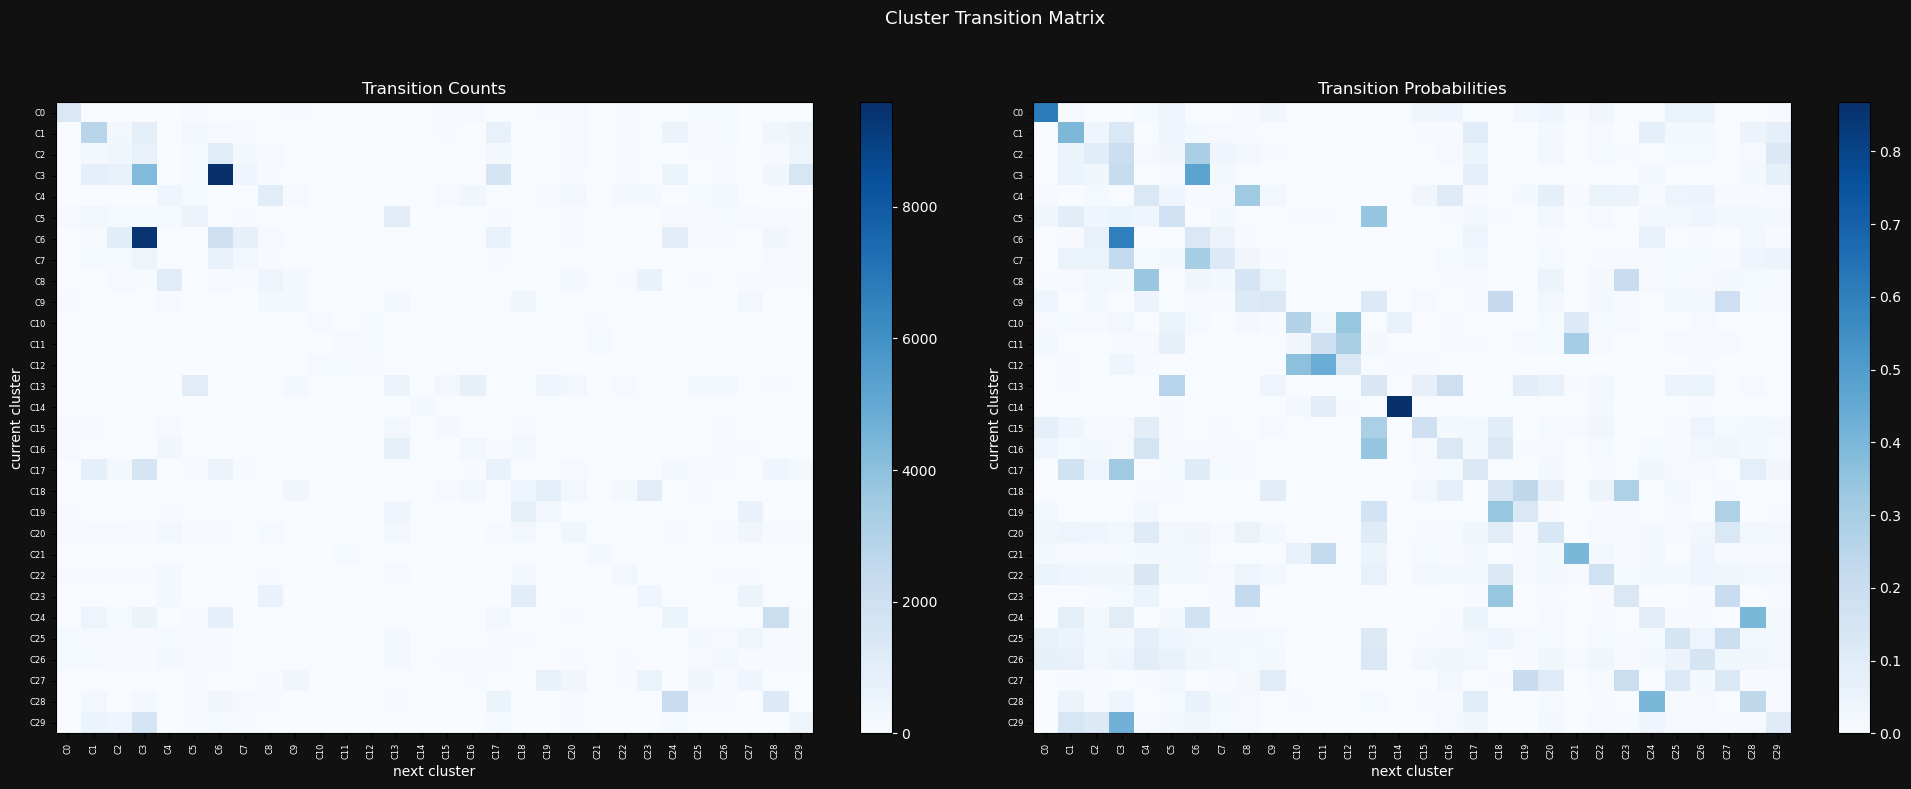

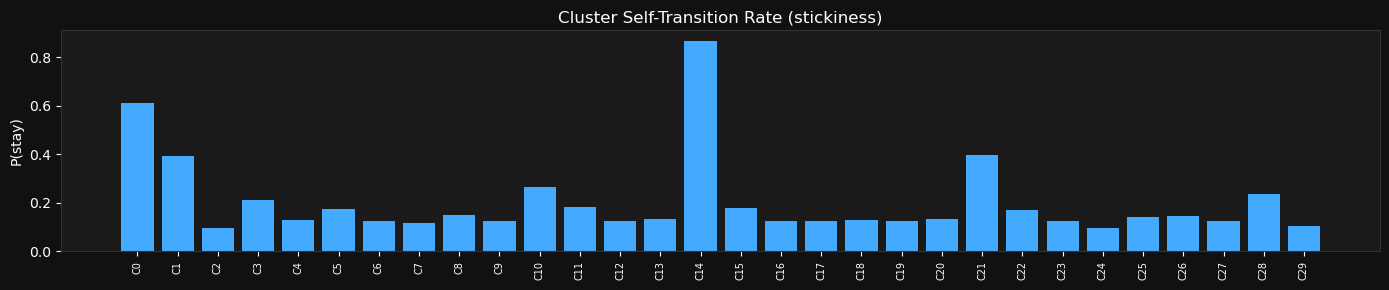

In [26]:
if features is None:
    print('No cluster data â€” skipping.')
else:
    trans = np.zeros((K, K), dtype=int)
    for mid, grp in meta_df.groupby('match_id'):
        seq = grp.sort_values('tick')['cluster'].values
        for a, b in zip(seq[:-1], seq[1:]):
            trans[a, b] += 1

    # Normalize rows
    row_sums = trans.sum(axis=1, keepdims=True).clip(1)
    trans_norm = trans / row_sums

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.patch.set_facecolor('#111')
    for ax, data, title in zip(axes, [trans, trans_norm], ['Transition Counts', 'Transition Probabilities']):
        ax.set_facecolor('#1a1a1a')
        im = ax.imshow(data, aspect='auto', cmap='Blues')
        ax.set_xticks(range(K)); ax.set_xticklabels([f'C{i}' for i in range(K)], rotation=90, color='white', fontsize=6)
        ax.set_yticks(range(K)); ax.set_yticklabels([f'C{i}' for i in range(K)], color='white', fontsize=6)
        ax.set_xlabel('next cluster', color='white'); ax.set_ylabel('current cluster', color='white')
        cb = plt.colorbar(im, ax=ax)
        cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
        ax.set_title(title, color='white')
    plt.suptitle('Cluster Transition Matrix', color='white', fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

    # Self-transition rate (how sticky each cluster is)
    self_trans = np.diag(trans_norm)
    fig, ax = plt.subplots(figsize=(14, 3))
    fig.patch.set_facecolor('#111'); ax.set_facecolor('#1a1a1a')
    ax.bar(range(K), self_trans, color='#44aaff')
    ax.set_xticks(range(K)); ax.set_xticklabels([f'C{i}' for i in range(K)], rotation=90, color='white', fontsize=7)
    ax.set_ylabel('P(stay)', color='white'); ax.set_title('Cluster Self-Transition Rate (stickiness)', color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')
    plt.tight_layout(); plt.show()

## 7. Replay Phase Summary â€” Cluster Log Analysis

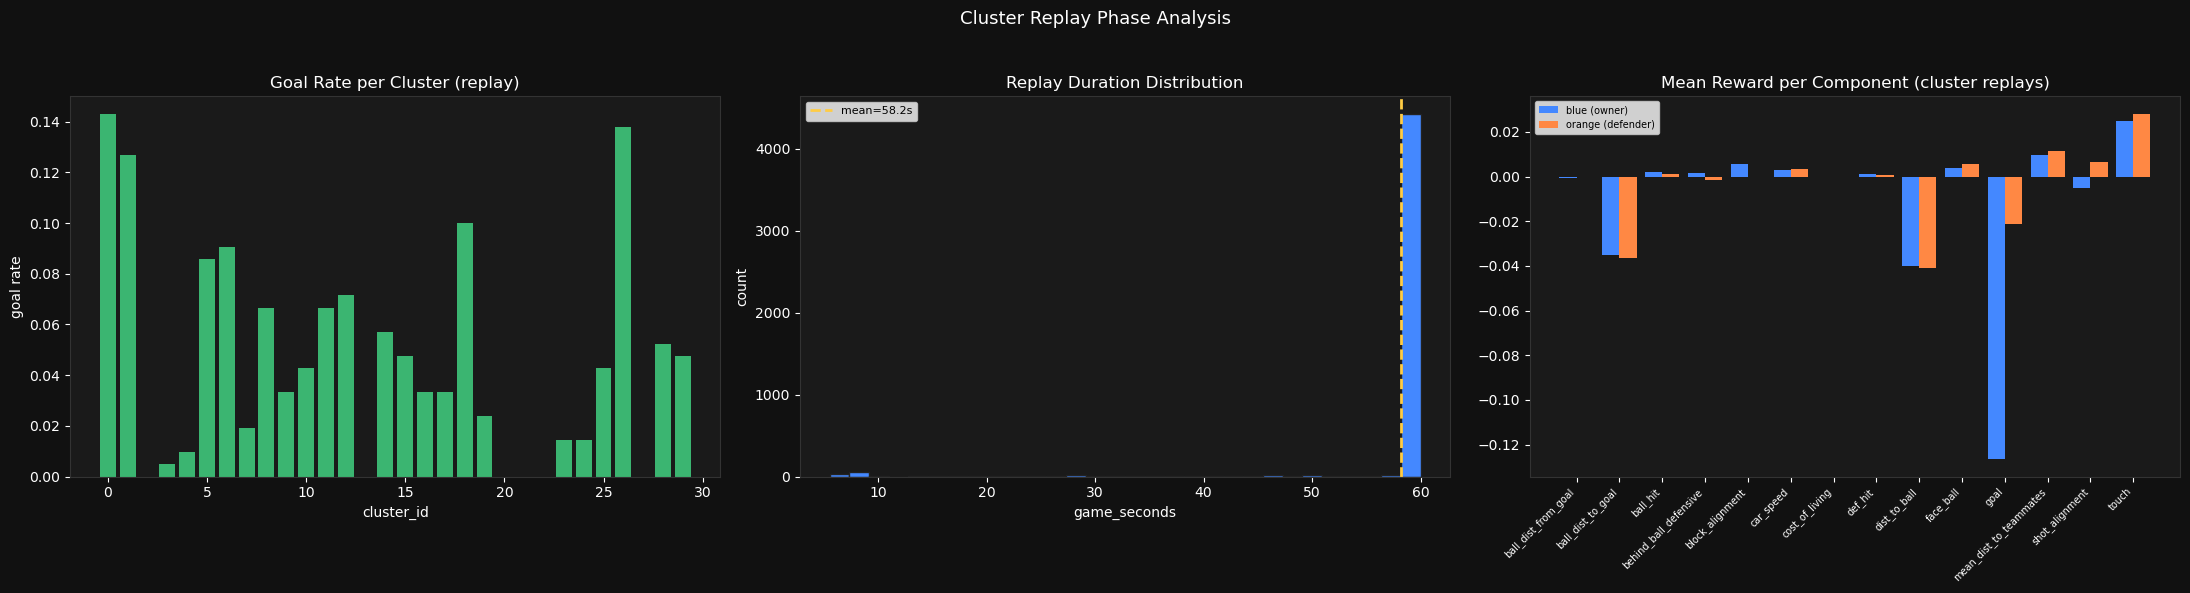


Top replay candidates (clusters by goal rate + density):
 cluster_id  goal_rate  avg_secs   n
          0   0.142857 53.451095 210
         26   0.138095 54.367238 210
          1   0.126667 53.508200 150
         18   0.100000 58.121810 210
          6   0.090476 58.644857 210
          5   0.085714 55.605429 210
         12   0.071429 58.350000  28
          8   0.066667 57.592000 210
         11   0.066667 59.254095 210
         14   0.057143 58.328905 210


In [27]:
if len(cl) == 0:
    print('No cluster log found â€” skipping.')
else:
    reward_cl_cols = [c for c in cl.columns if c.startswith('blue_') and c not in
                      ['blue_team'] and not c.endswith('_team')]
    reward_cl_keys = [c[5:] for c in reward_cl_cols]

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.patch.set_facecolor('#111')

    # Goal rate per cluster
    ax = axes[0]; ax.set_facecolor('#1a1a1a')
    by_cluster = cl.groupby('cluster_id').agg(
        goal_rate=('goal_scored','mean'),
        avg_secs=('game_seconds','mean'),
        n=('match_id','count')
    ).reset_index()
    ax.bar(by_cluster['cluster_id'], by_cluster['goal_rate'], color='#44dd88', alpha=0.8)
    ax.set_xlabel('cluster_id', color='white'); ax.set_ylabel('goal rate', color='white')
    ax.set_title('Goal Rate per Cluster (replay)', color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')

    # Game seconds distribution
    ax = axes[1]; ax.set_facecolor('#1a1a1a')
    ax.hist(cl['game_seconds'], bins=30, color='#4488ff', edgecolor='#222')
    ax.axvline(cl['game_seconds'].mean(), color='#ffcc44', lw=2, ls='--',
               label=f'mean={cl["game_seconds"].mean():.1f}s')
    ax.set_xlabel('game_seconds', color='white'); ax.set_ylabel('count', color='white')
    ax.set_title('Replay Duration Distribution', color='white'); ax.legend(fontsize=8)
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')

    # Mean reward per key (blue owner)
    ax = axes[2]; ax.set_facecolor('#1a1a1a')
    means_b_cl = [cl[f'blue_{k}'].mean() for k in reward_cl_keys]
    means_o_cl = [cl[f'orange_{k}'].mean() if f'orange_{k}' in cl.columns else 0 for k in reward_cl_keys]
    x = np.arange(len(reward_cl_keys))
    ax.bar(x-0.2, means_b_cl, 0.4, color='#4488ff', label='blue (owner)')
    ax.bar(x+0.2, means_o_cl, 0.4, color='#ff8844', label='orange (defender)')
    ax.set_xticks(x); ax.set_xticklabels(reward_cl_keys, rotation=45, ha='right', color='white', fontsize=7)
    ax.set_title('Mean Reward per Component (cluster replays)', color='white'); ax.legend(fontsize=7)
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')

    plt.suptitle('Cluster Replay Phase Analysis', color='white', fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

    # Best replay candidates
    print('\nTop replay candidates (clusters by goal rate + density):')
    ranked = by_cluster.sort_values(['goal_rate','n'], ascending=False).head(10)
    print(ranked.to_string(index=False))

## 8. Single Match Deep-Dive

Match: 1022)team6_def_striker__v__team4_pos_striker  |  4503 rows  |  300.0s


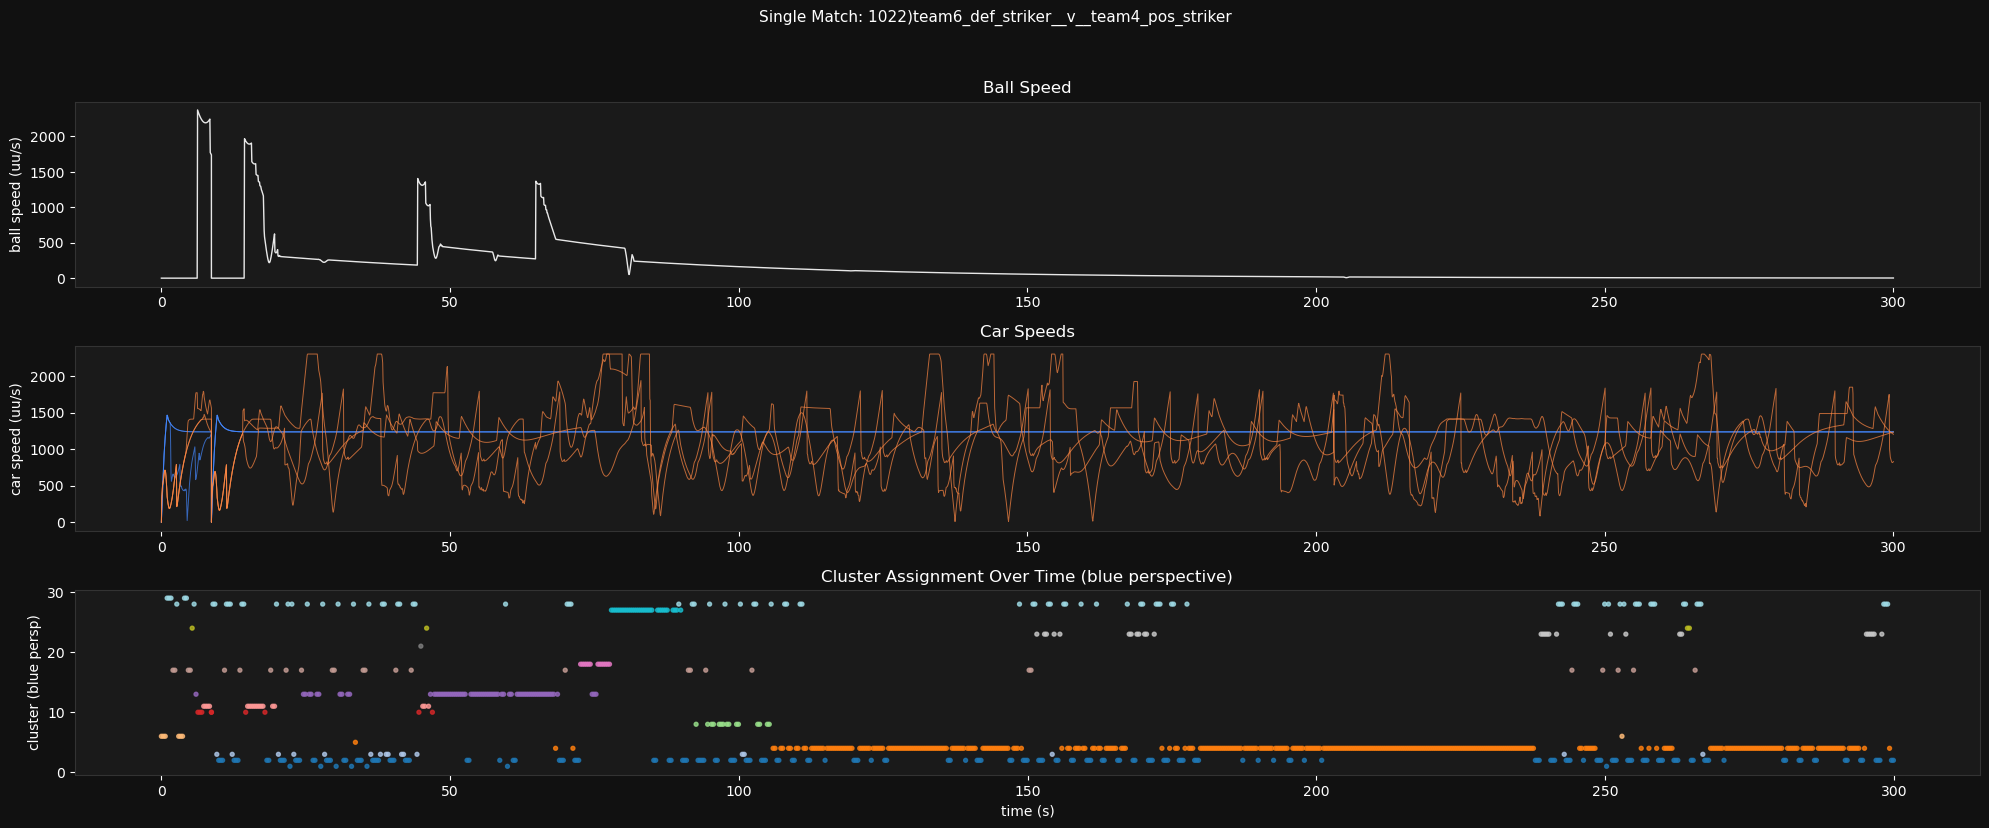

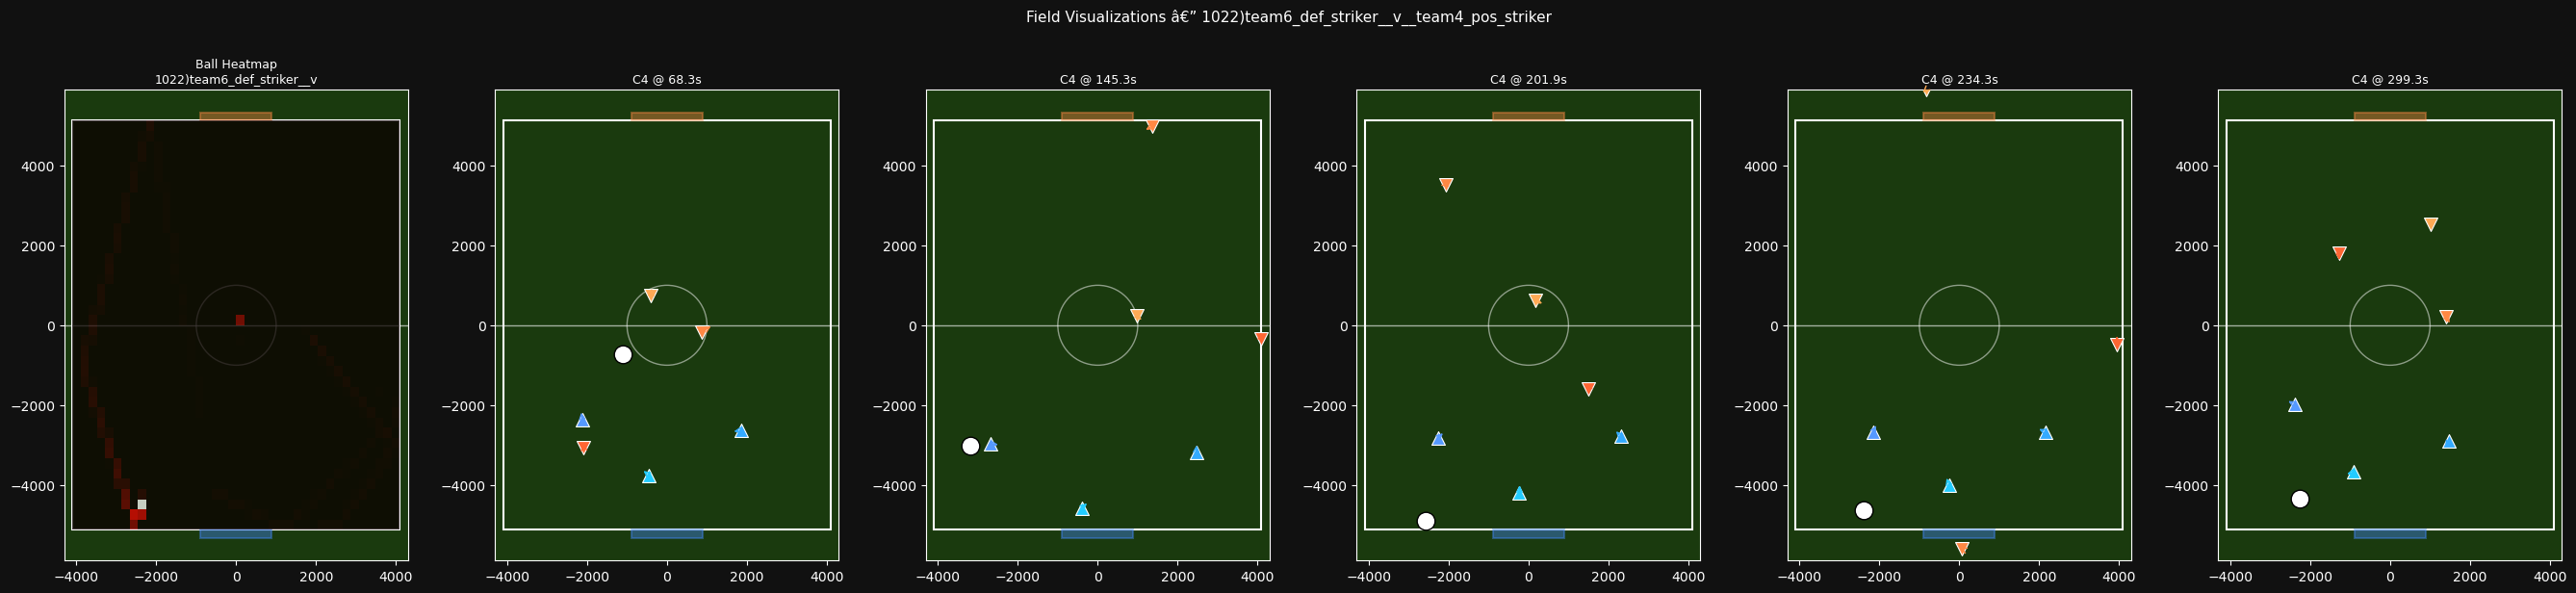

In [31]:
# â”€â”€ Config â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
INSPECT_IDX = 9   # index into csv_files list (0 = first file)
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

if not csv_files:
    print('No high-level log files found.')
else:
    fpath = csv_files[INSPECT_IDX % len(csv_files)]
    match_label = os.path.basename(fpath).replace('.csv','')
    hl = pd.read_csv(fpath)
    print(f'Match: {match_label}  |  {len(hl)} rows  |  {hl["time_s"].max():.1f}s')

    bspd  = ball_speed(hl)
    slots = [f'{side}-{i}' for side in ['blue','orange'] for i in range(3)]
    speeds = {s: car_speed(hl, s) for s in slots if f'{s}_vx' in hl.columns}

    # â”€â”€ Attach cluster labels if available â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    mid_val = hl['match_id'].iloc[0] if 'match_id' in hl.columns else int(match_label.split(')')[0])
    hl_clust = None
    if features is not None:
        sub = meta_df[(meta_df['match_id']==mid_val) & (meta_df['perspective']=='blue')]
        if len(sub) > 0:
            tick_to_cluster = dict(zip(sub['tick'], sub['cluster']))
            hl['cluster_blue'] = hl['tick'].map(tick_to_cluster)
            hl_clust = hl.dropna(subset=['cluster_blue'])
            hl_clust = hl_clust.copy()
            hl_clust['cluster_blue'] = hl_clust['cluster_blue'].astype(int)

    # â”€â”€ Row 1: Wide graphs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    n_wide = 3 if hl_clust is not None else 2
    fig, axes = plt.subplots(n_wide, 1, figsize=(20, 2.8*n_wide))
    fig.patch.set_facecolor('#111')
    if n_wide == 1: axes = [axes]

    ax = axes[0]; ax.set_facecolor('#1a1a1a')
    ax.plot(hl['time_s'], bspd, color='white', lw=1, alpha=0.9, label='ball speed')
    ax.set_ylabel('ball speed (uu/s)', color='white'); ax.set_title('Ball Speed', color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')

    ax = axes[1]; ax.set_facecolor('#1a1a1a')
    for s, spd in speeds.items():
        col = '#4488ff' if s.startswith('blue') else '#ff8844'
        ax.plot(hl['time_s'], spd, lw=0.7, alpha=0.7, color=col, label=s)
    ax.set_ylabel('car speed (uu/s)', color='white'); ax.set_title('Car Speeds', color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#333')

    if hl_clust is not None and n_wide >= 3:
        ax = axes[2]; ax.set_facecolor('#1a1a1a')
        sc = ax.scatter(hl_clust['time_s'], hl_clust['cluster_blue'],
                        c=hl_clust['cluster_blue'], cmap='tab20', s=8, alpha=0.8)
        ax.set_ylabel('cluster (blue persp)', color='white')
        ax.set_title('Cluster Assignment Over Time (blue perspective)', color='white')
        ax.set_xlabel('time (s)', color='white'); ax.tick_params(colors='white')
        for sp in ax.spines.values(): sp.set_color('#333')
        axes[-1].set_xlabel('time (s)', color='white')
    else:
        axes[-1].set_xlabel('time (s)', color='white')

    plt.suptitle(f'Single Match: {match_label}', color='white', fontsize=11)
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

    # â”€â”€ Row 2: Field visualizations â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # Find 5 densest same-cluster ticks (most common cluster in this match)
    FIELD_COLS = 6  # ball heatmap + 5 cluster snapshots
    fig2, axes2 = plt.subplots(1, FIELD_COLS, figsize=(FIELD_COLS*4.5, 6))
    fig2.patch.set_facecolor('#111')

    # Ball heatmap for this match
    ax = axes2[0]
    h, xe, ye = np.histogram2d(hl['ball_px'], hl['ball_py'],
                                bins=40, range=[[-FIELD_X,FIELD_X],[-FIELD_Y,FIELD_Y]])
    draw_field(ax, f'Ball Heatmap\n{match_label[:25]}')
    ax.pcolormesh(xe, ye, h.T, cmap='hot', alpha=0.75, zorder=2)

    # 5 observations from the densest cluster
    if hl_clust is not None and len(hl_clust) >= 5:
        dominant_cluster = hl_clust['cluster_blue'].value_counts().idxmax()
        cluster_rows = hl_clust[hl_clust['cluster_blue'] == dominant_cluster]
        # pick 5 evenly spaced
        idx5 = np.linspace(0, len(cluster_rows)-1, 5, dtype=int)
        samples = cluster_rows.iloc[idx5]

        for i, (_, row) in enumerate(samples.iterrows()):
            ax = axes2[1+i]
            t_str = f'{row["time_s"]:.1f}s'
            draw_field(ax, f'C{dominant_cluster} @ {t_str}')
            # Ball
            ax.scatter([row['ball_px']], [row['ball_py']], s=180, color='white', zorder=5,
                       edgecolors='black', lw=1)
            bvx = row.get('ball_vx',0)*0.25; bvy = row.get('ball_vy',0)*0.25
            if abs(bvx)+abs(bvy) > 50:
                ax.annotate('', xy=(row['ball_px']+bvx, row['ball_py']+bvy),
                            xytext=(row['ball_px'], row['ball_py']),
                            arrowprops=dict(arrowstyle='->', color='white', lw=1.5), zorder=6)
            # Cars
            for side, marker, colors in [
                ('blue', '^', ['#5599ff','#33aaff','#22ccff']),
                ('orange', 'v', ['#ff6633','#ff8844','#ffaa55'])
            ]:
                for j, col in enumerate(colors):
                    slot = f'{side}-{j}'
                    px_c = row.get(f'{slot}_px'); py_c = row.get(f'{slot}_py')
                    if pd.isna(px_c): continue
                    ax.scatter([px_c], [py_c], s=100, color=col, zorder=4,
                               marker=marker, edgecolors='white', lw=0.8)
                    vx_c = row.get(f'{slot}_vx',0)*0.2; vy_c = row.get(f'{slot}_vy',0)*0.2
                    if abs(vx_c)+abs(vy_c) > 30:
                        ax.annotate('', xy=(px_c+vx_c, py_c+vy_c), xytext=(px_c, py_c),
                                    arrowprops=dict(arrowstyle='->', color=col, lw=1), zorder=5)
    else:
        for ax in axes2[1:]:
            ax.set_visible(False)

    plt.suptitle(f'Field Visualizations â€” {match_label}', color='white', fontsize=11)
    plt.tight_layout(rect=[0,0,1,0.93]); plt.show()